In [2]:
import pandas as pd

df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
print(df.isnull().sum())


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 62.5 KB


In [ ]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.817590,0.653094,0.744300,0.218241,0.133550,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.037459,0.687296
std,0.386497,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


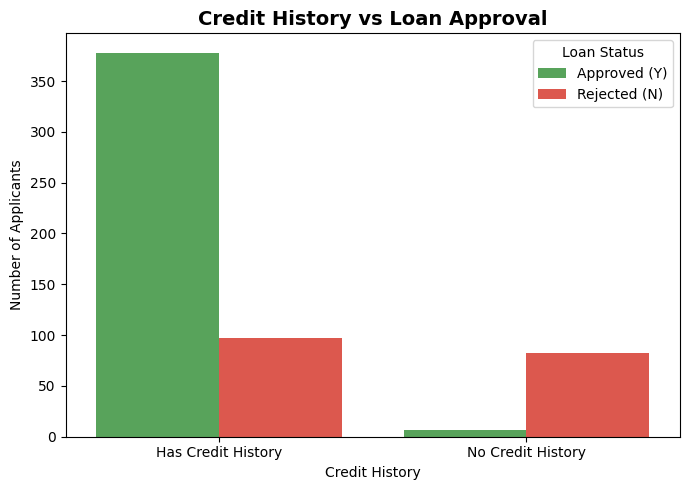

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Clean label so the chart is readable
df["Credit_History_Label"] = df["Credit_History"].map({
    1.0: "Has Credit History",
    0.0: "No Credit History"
})

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Credit_History_Label",
    hue="Loan_Status",
    palette={"Y": "#4CAF50", "N": "#F44336"}
)

plt.title("Credit History vs Loan Approval", fontsize=14, fontweight="bold")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Approved (Y)", "Rejected (N)"])
plt.tight_layout()
plt.show()

C:\Users\rokai\AppData\Local\Temp\ipykernel_8404\61401220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


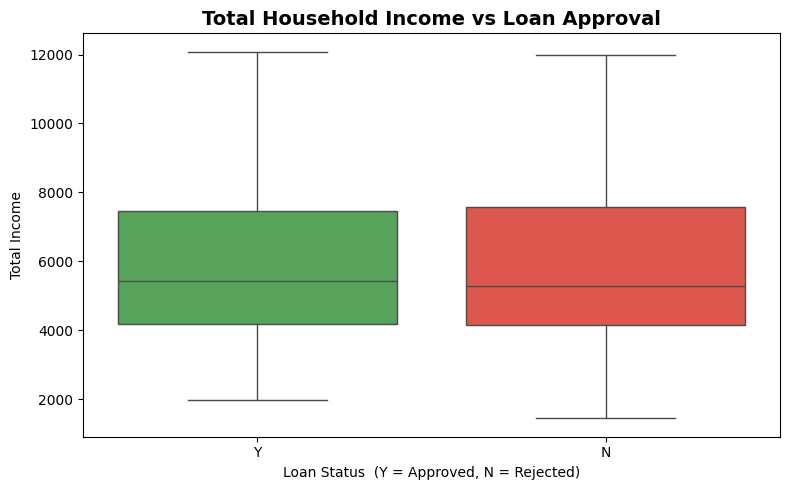

In [ ]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="TotalIncome",
    palette={"Y": "#4CAF50", "N": "#F44336"},
    showfliers=False
)

plt.title("Total Household Income vs Loan Approval", fontsize=14, fontweight="bold")
plt.xlabel("Loan Status  (Y = Approved, N = Rejected)")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()

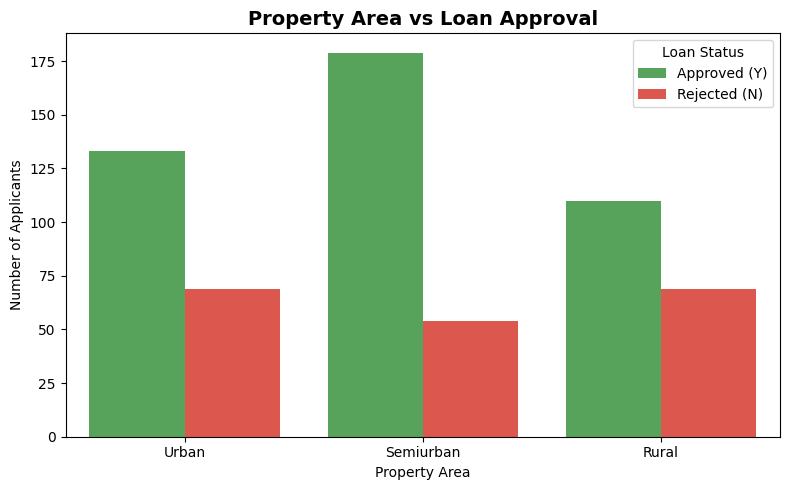

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status",
    order=["Urban", "Semiurban", "Rural"],
    palette={"Y": "#4CAF50", "N": "#F44336"}
)

plt.title("Property Area vs Loan Approval", fontsize=14, fontweight="bold")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Approved (Y)", "Rejected (N)"])
plt.tight_layout()
plt.show()

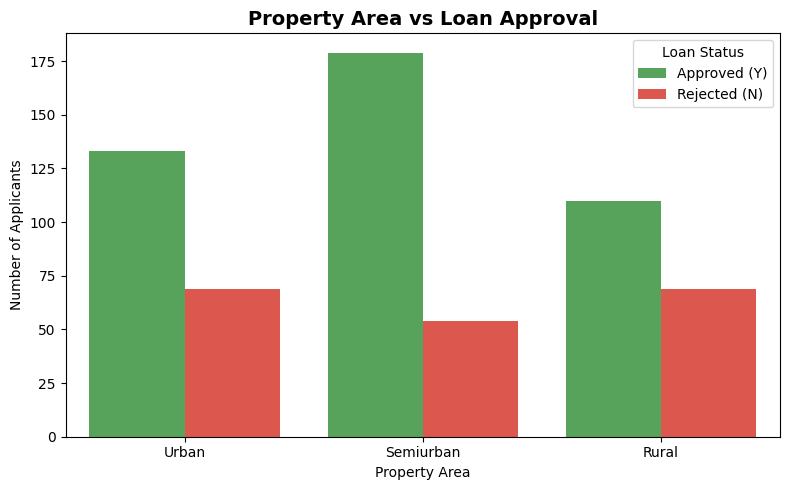

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status",
    order=["Urban", "Semiurban", "Rural"],
    palette={"Y": "#4CAF50", "N": "#F44336"}
)

plt.title("Property Area vs Loan Approval", fontsize=14, fontweight="bold")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Approved (Y)", "Rejected (N)"])
plt.tight_layout()
plt.show()